# 05 — Perturbation Sensitivity and the Mask-in-Place Control

**Manuscript section:** Results §5 — *Embedding geometry predicts perturbation sensitivity in Geneformer*

**Manuscript figures:** Fig 3a–d

In silico gene deletion and mask-in-place perturbation experiments for Geneformer,
with cross-model comparison to scGPT.

**Data inputs:**
- `data/perturbation_sensitivity.csv` (95 genes, synthetic cell delete shifts)
- `data/perturbation_real_pbmc.csv` (real PBMC validation)
- `data/perturbation_synthetic_vs_real.csv` (synthetic-real rank agreement)
- `data/mask_perturbation_comparison.csv` (mask vs delete comparison)
- `data/scgpt_perturbation_sensitivity.csv` (scGPT delete shifts)



In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*is_categorical_dtype.*')

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu

import glitch_style
importlib.reload(glitch_style)
from glitch_style import CONTROL_COLOR, FIG_SINGLE, GLITCH_COLOR, NEUTRAL_COLOR, apply_style, save_fig

# ── Verify required inputs exist ──
from pathlib import Path
assert Path('data/perturbation_sensitivity.csv').exists(), "Missing data/perturbation_sensitivity.csv — run P06 first"

In [2]:
perturb = pd.read_csv('data/perturbation_sensitivity.csv')
mask = pd.read_csv('data/mask_perturbation_comparison.csv')

print(f'Perturbation data: {len(perturb)} genes')
print(f'  Glitch: {(perturb["group"]=="glitch").sum()}, Control: {(perturb["group"]=="control").sum()}')
print(f'Mask comparison: {len(mask)} genes')

Perturbation data: 95 genes
  Glitch: 50, Control: 45
Mask comparison: 95 genes


## Fig 4a — Anomaly score vs perturbation shift (Geneformer)

Saved: figs/Fig4a_anomaly_vs_shift.pdf, figs/Fig4a_anomaly_vs_shift.png


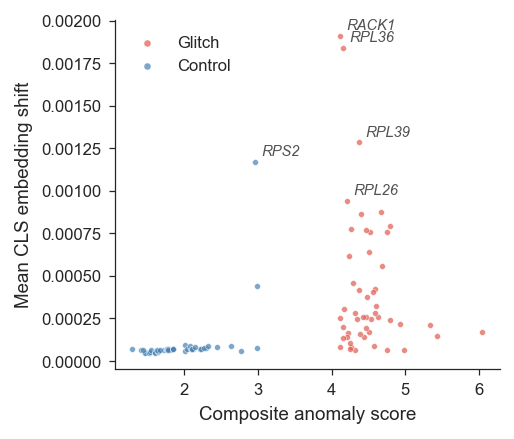


Fig 3a stats: rho=0.7249, p=9.97e-17


In [3]:
apply_style()

fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')

for grp, color, label in [('glitch', GLITCH_COLOR, 'Glitch'), ('control', CONTROL_COLOR, 'Control')]:
    sub = perturb[perturb['group'] == grp]
    ax.scatter(sub['anomaly_score'], sub['mean_shift'], color=color, s=8, alpha=0.7,
               label=label, edgecolors='white', linewidth=0.3)

# Label top 5 destabilisers
top5 = perturb.nlargest(5, 'mean_shift')
texts = []
for _, row in top5.iterrows():
    t = ax.annotate(row['gene'], (row['anomaly_score'], row['mean_shift']),
                    fontsize=7, fontstyle='italic', alpha=0.8,
                    xytext=(3, 3), textcoords='offset points')
    texts.append(t)

rho, p = spearmanr(perturb['anomaly_score'], perturb['mean_shift'])
ax.set_xlabel('Composite anomaly score')
ax.set_ylabel('Mean CLS embedding shift')

# Stats printed below (kept in caption, not on plot)

ax.legend(markerscale=1.2)
sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig4a_anomaly_vs_shift')
plt.show()

print(f'\nFig 3a stats: rho={rho:.4f}, p={p:.2e}')


## Fig 4b — Synthetic vs real PBMC validation

Saved: figs/Fig4b_synthetic_vs_real.pdf, figs/Fig4b_synthetic_vs_real.png


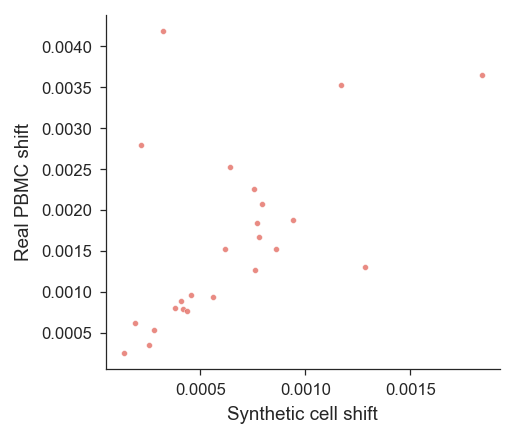


Fig 3b stats (synthetic vs real rank): rho=0.5800, p=0.0030
Anomaly vs real shift: rho=0.2530, p=0.2329


In [4]:
try:
    synth_real = pd.read_csv('data/perturbation_synthetic_vs_real.csv')

    # Normalise column names (P06 may use different naming conventions)
    col_map = {}
    for old, new in [('synthetic_mean_shift', 'mean_shift'),
                     ('pbmc_mean_shift', 'mean_shift_nb03')]:
        if old in synth_real.columns and new not in synth_real.columns:
            col_map[old] = new
    if col_map:
        synth_real = synth_real.rename(columns=col_map)
    # Verify expected columns exist after rename
    for expected in ['mean_shift']:
        assert expected in synth_real.columns, f'Missing {expected} after col_map rename'

    fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')

    ax.scatter(synth_real['mean_shift'], synth_real['mean_shift_nb03'],
               s=8, color=GLITCH_COLOR, alpha=0.7, edgecolors='white', linewidth=0.3)

    rho, p = spearmanr(synth_real['mean_shift'], synth_real['mean_shift_nb03'])
    ax.set_xlabel('Synthetic cell shift')
    ax.set_ylabel('Real PBMC shift')

    # Stats printed below (kept in caption, not on plot)

    sns.despine()
    fig.tight_layout()
    save_fig(fig, 'Fig4b_synthetic_vs_real')
    plt.show()

    print(f'\nFig 3b stats (synthetic vs real rank): rho={rho:.4f}, p={p:.4f}')

    # Also check anomaly vs real shift (claimed in manuscript)
    if 'anomaly_score' in synth_real.columns:
        rho2, p2 = spearmanr(synth_real['anomaly_score'], synth_real['mean_shift_nb03'])
        print(f'Anomaly vs real shift: rho={rho2:.4f}, p={p2:.4f}')

except FileNotFoundError:
    print('Synthetic vs real CSV not found; see gf_04a_real_data_validation.ipynb')


## Fig 4c — Mask-in-place vs delete scatter

Saved: figs/Fig4c_mask_vs_delete.pdf, figs/Fig4c_mask_vs_delete.png


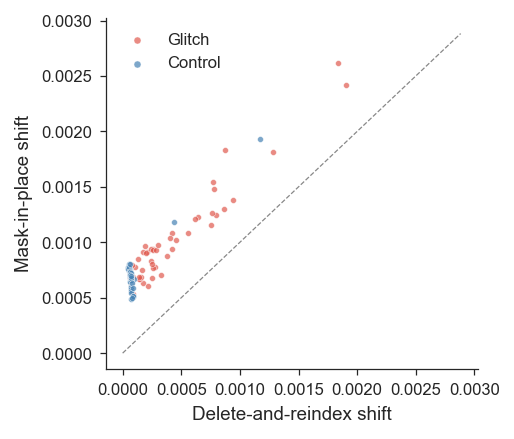


Fig 3c: Mask shift glitch vs control MWU p=1.45e-07
Anomaly vs delete shift: rho=0.7249 (manuscript: 0.725)
Anomaly vs mask shift: rho=0.4022 (manuscript: 0.402)


In [5]:
fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')

for grp, color in [('glitch', GLITCH_COLOR), ('control', CONTROL_COLOR)]:
    sub = mask[mask['group'] == grp]
    ax.scatter(sub['delete_shift'], sub['mask_shift'], color=color, s=8, alpha=0.7,
               label=grp.capitalize(), edgecolors='white', linewidth=0.3)

# Diagonal reference
lims = [0, max(mask['mask_shift'].max(), mask['delete_shift'].max()) * 1.1]
ax.plot(lims, lims, '--', color=NEUTRAL_COLOR, linewidth=0.6)

ax.set_xlabel('Delete-and-reindex shift')
ax.set_ylabel('Mask-in-place shift')
ax.legend(markerscale=1.2)
sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig4c_mask_vs_delete')
plt.show()

# Stats
g = mask[mask['group'] == 'glitch']['mask_shift']
c = mask[mask['group'] == 'control']['mask_shift']
U, p = mannwhitneyu(g, c, alternative='two-sided')
print(f'\nFig 3c: Mask shift glitch vs control MWU p={p:.2e}')

rho_del, _ = spearmanr(mask['anomaly_score'], mask['delete_shift'])
rho_mask, _ = spearmanr(mask['anomaly_score'], mask['mask_shift'])
print(f'Anomaly vs delete shift: rho={rho_del:.4f} (manuscript: 0.725)')
print(f'Anomaly vs mask shift: rho={rho_mask:.4f} (manuscript: 0.402)')


## Fig 4d — GF vs scGPT perturbation asymmetry

Saved: figs/Fig4d_perturbation_asymmetry.pdf, figs/Fig4d_perturbation_asymmetry.png


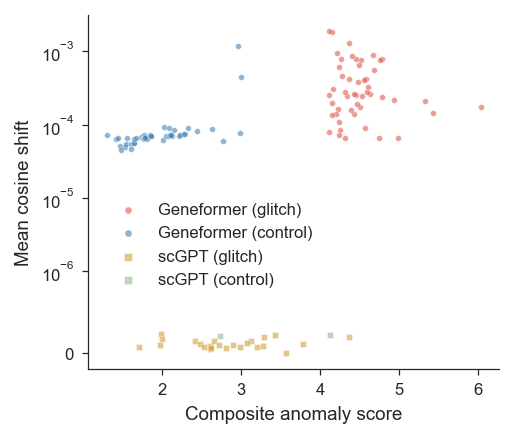


Fig 3d stats:
  Geneformer: rho=0.7249, p=9.97e-17 (n=95)
  Median GF shift:    8.92e-05
  Median scGPT shift: 1.07e-07
  Ratio: 830×
  scGPT: n=26 testable genes (24 glitch, 2 control)
  NOTE: scGPT correlation not reported — shifts are at the numerical
        noise floor (~10⁻⁸ cosine), making rank-based correlation
        unstable across independent runs. The 24:2 class
        imbalance further precludes meaningful group comparison.


In [6]:
sc_perturb = pd.read_csv('data/scgpt_perturbation_sensitivity.csv')

fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')

# Geneformer: anomaly score vs mean shift (all 95 genes)
for grp, color in [('glitch', GLITCH_COLOR), ('control', CONTROL_COLOR)]:
    sub = perturb[perturb['group'] == grp]
    ax.scatter(sub['anomaly_score'], sub['mean_shift'], color=color, s=8, alpha=0.6,
               edgecolors='white', linewidth=0.3, label=f'Geneformer ({grp})')

# scGPT: anomaly score vs mean shift (26 genes)
for grp, color in [('glitch', '#D4A03C'), ('control', '#8FBC8F')]:
    sub = sc_perturb[sc_perturb['group'] == grp]
    ax.scatter(sub['anomaly_score'], sub['mean_shift'], color=color, s=8, alpha=0.6,
               marker='s', edgecolors='white', linewidth=0.3, label=f'scGPT ({grp})')

ax.set_yscale('symlog', linthresh=1e-6)
ax.set_xlabel('Composite anomaly score')
ax.set_ylabel('Mean cosine shift')
ax.legend(markerscale=1.2, loc='center left', bbox_to_anchor=(0.02, 0.35))
sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig4d_perturbation_asymmetry')
plt.show()

# Summary stats
rho_gf, p_gf = spearmanr(perturb['anomaly_score'], perturb['mean_shift'])
med_gf = perturb['mean_shift'].median()
med_sc = sc_perturb['mean_shift'].median()
n_glitch = (sc_perturb['group'] == 'glitch').sum()
n_control = (sc_perturb['group'] == 'control').sum()
print(f'\nFig 3d stats:')
print(f'  Geneformer: rho={rho_gf:.4f}, p={p_gf:.2e} (n={len(perturb)})')
print(f'  Median GF shift:    {med_gf:.2e}')
print(f'  Median scGPT shift: {med_sc:.2e}')
print(f'  Ratio: {med_gf / med_sc:.0f}\u00d7')
print(f'  scGPT: n={len(sc_perturb)} testable genes ({n_glitch} glitch, {n_control} control)')
print(f'  NOTE: scGPT correlation not reported \u2014 shifts are at the numerical')
print(f'        noise floor (~10\u207b\u2078 cosine), making rank-based correlation')
print(f'        unstable across independent runs. The {n_glitch}:{n_control} class')
print(f'        imbalance further precludes meaningful group comparison.')
